In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

Some easy stats can be pulled from the dataset, already those counts need investigation.

In [ ]:
df = pd.read_csv('AssessmentData/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,NW,2.4,Aotizhongxin
35060,35061,2017,2,28,20,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Aotizhongxin
35061,35062,2017,2,28,21,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,NW,1.1,Aotizhongxin
35062,35063,2017,2,28,22,21.0,44.0,12.0,87.0,700.0,35.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Aotizhongxin


Unsurprisingly the dataset contains some entries that will need attention before our analysis proper.

In [75]:
df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

## Moments
We can forget Gaussian distribution, the stats suggest the pollution stats all have a positive skew; while CO and SO2 has significant tails.

In [76]:
for i in ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']:
    print(f'Component {i}\tmean: {df[i].mean():.2f}\tvariance: {df[i].std()**2:.2f}\tskew: {df[i].skew():.2f}\tkurtosis: {df[i].kurtosis():.2f}\tmedian: {df[i].median():.2f}')

Component PM2.5	mean: 82.77	variance: 6746.27	skew: 1.97	kurtosis: 5.57	median: 58.00
Component PM10	mean: 110.06	variance: 9067.42	skew: 1.78	kurtosis: 5.38	median: 87.00
Component SO2	mean: 17.38	variance: 520.89	skew: 2.80	kurtosis: 10.79	median: 9.00
Component NO2	mean: 59.31	variance: 1377.61	skew: 0.93	kurtosis: 1.04	median: 53.00
Component CO	mean: 1262.95	variance: 1491906.48	skew: 2.56	kurtosis: 8.81	median: 900.00
Component O3	mean: 56.35	variance: 3354.30	skew: 1.44	kurtosis: 2.18	median: 42.00


In [122]:
def get_moments(file):
    for i in ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']:
        print(f'Component {i}\tmean: {file[i].mean():.2f}\tvariance: {file[i].std()**2:.2f}\tskew: {file[i].skew():.2f}\tkurtosis: {file[i].kurtosis():.2f}\tmedian: {file[i].median():.2f}')

## Distributions
 '''Lies, damned lies, and statistics - Mark Twain, attributed to Benjamin Disraeli''' (wikipedia, 2025)

As computer scientists, we continuouly lie to each other. We pretend that random varaibles are iid, when they are not. We take solice in the Law of Large Numbers and Central Limit Theorum, believing everything collapses to a Gaussian distribution, if we throw enough data at the problem. '''(*)'''

Which can be visualised by some lovely distributions. The question will be do all (or at least the 4 chosen) follow the same distributions. The visualisation throws up some intersting artifacts to investigate in NO2 and O3. 

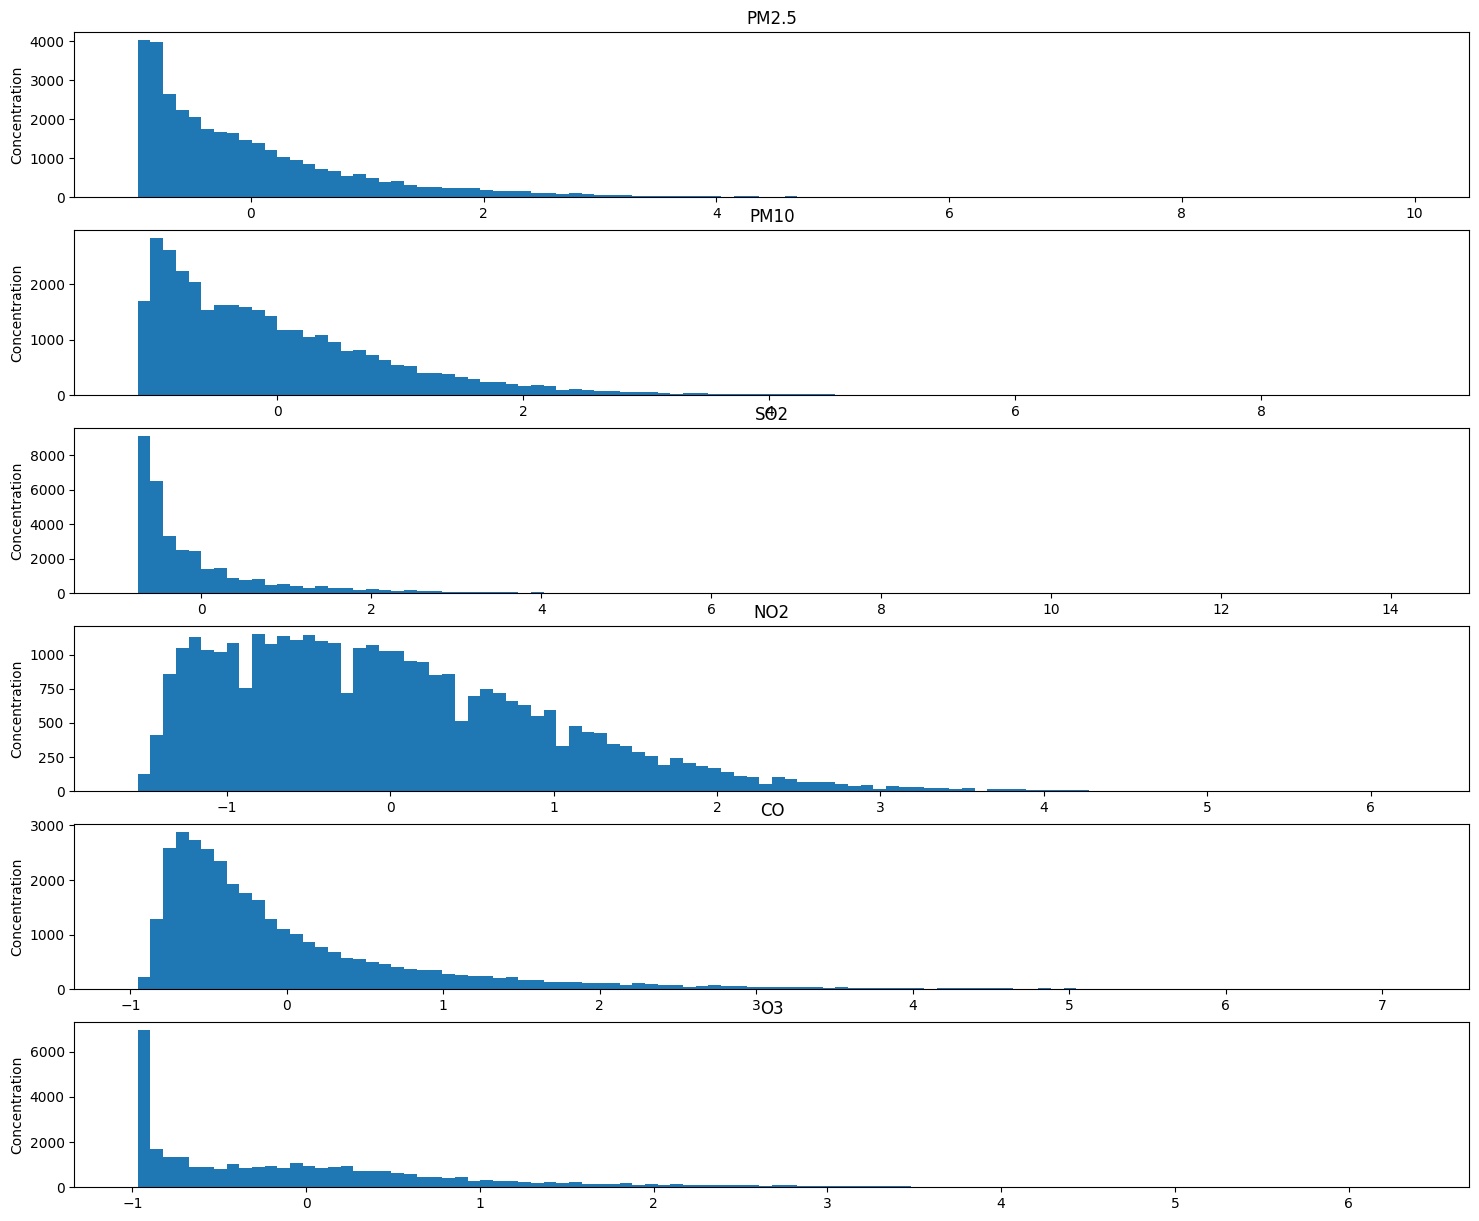

In [77]:
fig, ax = plt.subplots(6, 1, figsize=(18, 15))#, sharex=True)

for i, v in enumerate(['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']):
    ax[i].hist((df[v]-df[v].mean())/df[v].std(), bins=100)
    ax[i].set(title=v,
            ylabel='Concentration')

plt.show()

Autocorrelation
Correlation
Seasonality


## Correlation
Some interesting correlations there, unsurprisingly PM2.5 is highly correlated with PM10, with significant correlations with CO, NO2 and SO2

In [78]:
df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].corr(method='pearson')

,PM2.5,PM10,SO2,NO2,CO,O3
PM2.5,1.000000,0.879104,0.481025,0.684986,0.785006,-0.161448
PM10,0.879104,1.000000,0.469045,0.652325,0.680404,-0.139914
SO2,0.481025,0.469045,1.000000,0.432081,0.540275,-0.200193
NO2,0.684986,0.652325,0.432081,1.000000,0.690202,-0.500380
CO,0.785006,0.680404,0.540275,0.690202,1.000000,-0.326462
O3,-0.161448,-0.139914,-0.200193,-0.500380,-0.326462,1.000000


## Autocorrelation
Most look fairly reasonable, but what's going on with Ozone? A two year cycle?! Granted not the full picture, but Cool!

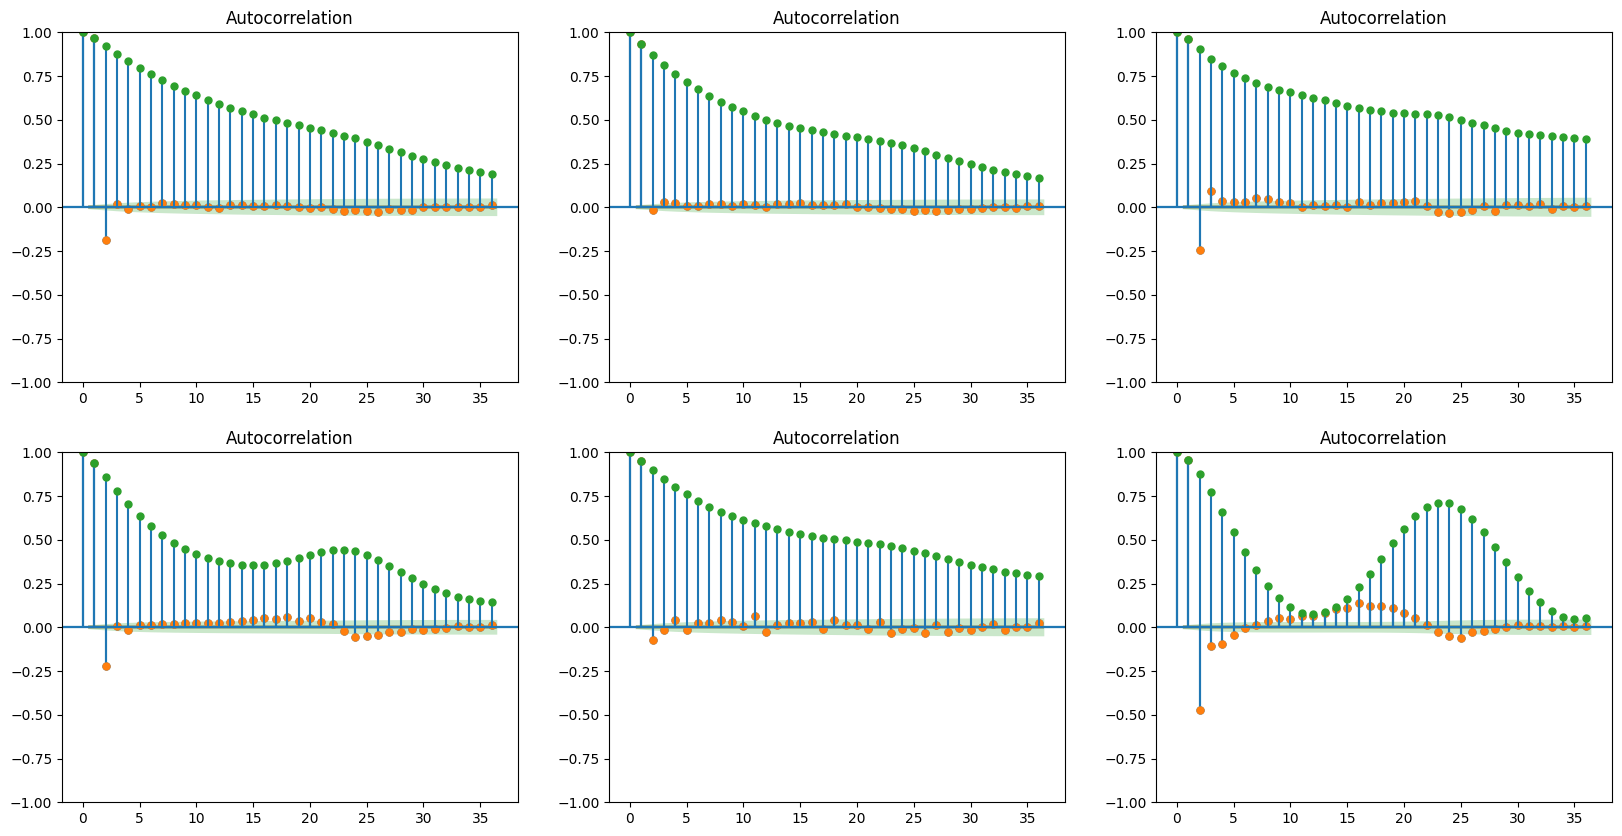

In [97]:
#fig, axes = plt.subplots(2, 3, figsize=(20, 10))
plot_acf(df['PM2.5'].dropna(), lags=36, ax=axes[0, 0])
plot_acf(df['PM10'].dropna(), lags=36, ax=axes[0, 1])
plot_acf(df['SO2'].dropna(), lags=36, ax=axes[0, 2])
plot_acf(df['NO2'].dropna(), lags=36, ax=axes[1, 0])
plot_acf(df['CO'].dropna(), lags=36, ax=axes[1, 1])
plot_acf(df['O3'].dropna(), lags=36, ax=axes[1, 2])

In [102]:
result = adfuller(df['O3'].dropna())
pval = result[1]
print(pval)

4.711879608846599e-19


## All files
Let's load everything to do some comparisons. There's something I want to see if I can derive from one of the papers in the assignment brief.

Need to recheck the paper for exact wording but the 4 suburban districts all seem to have lower mean values for pollution:
Changpingzhen   CP Suburban 116.230 40.195 3–5
Dingling        DL Suburban 116.170 40.287 3–5
Huairouzhen     HR Suburban 116.644 40.394 3–5
Shunyixincheng  SY Suburban 116.720 40.144 3–5

In [132]:
import os
from pathlib import Path

def describe(file: Path):
    if any(name in file.name for name in ['Huairou', 'Shunyi', 'Nongzhanguan', 'Dongsi']):
        tmp = pd.read_csv(file)
        print(file)
        #get_moments(tmp)
    
for file in Path('./AssessmentData').iterdir():
    describe(file)

#os.listdir(data_path)



AssessmentData/PRSA_Data_Shunyi_20130301-20170228.csv
AssessmentData/PRSA_Data_Nongzhanguan_20130301-20170228.csv
AssessmentData/PRSA_Data_Dongsi_20130301-20170228.csv
AssessmentData/PRSA_Data_Huairou_20130301-20170228.csv


# References
wikipedia (2025), _Lies, damned lies, and statistics_. Available at: https://en.wikipedia.org/wiki/Lies,_damned_lies,_and_statistics (Accessed: 19/2/2026)